In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from faker import Faker

fake = Faker('ar_AA') 
arabic_names = []
for _ in range(50000):
    arabic_names.append(fake.first_name())

with open('arabic_names.txt', 'w', encoding='utf-8') as f:
    for name in arabic_names:
        f.write(name + '\n')
        
print("Generated 50,000 single first names!")

Generated 50,000 single first names!


In [4]:
names = open('./arabic_names.txt', 'r', encoding='utf-8').read().splitlines()

In [5]:
chars = sorted(list(set(''.join(names))))
chars

[' ',
 'ء',
 'آ',
 'أ',
 'ؤ',
 'إ',
 'ئ',
 'ا',
 'ب',
 'ة',
 'ت',
 'ث',
 'ج',
 'ح',
 'خ',
 'د',
 'ذ',
 'ر',
 'ز',
 'س',
 'ش',
 'ص',
 'ض',
 'ط',
 'ظ',
 'ع',
 'غ',
 'ف',
 'ق',
 'ك',
 'ل',
 'م',
 'ن',
 'ه',
 'و',
 'ى',
 'ي',
 'َ',
 'ُ',
 'ّ']

In [6]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
stoi

{' ': 1,
 'ء': 2,
 'آ': 3,
 'أ': 4,
 'ؤ': 5,
 'إ': 6,
 'ئ': 7,
 'ا': 8,
 'ب': 9,
 'ة': 10,
 'ت': 11,
 'ث': 12,
 'ج': 13,
 'ح': 14,
 'خ': 15,
 'د': 16,
 'ذ': 17,
 'ر': 18,
 'ز': 19,
 'س': 20,
 'ش': 21,
 'ص': 22,
 'ض': 23,
 'ط': 24,
 'ظ': 25,
 'ع': 26,
 'غ': 27,
 'ف': 28,
 'ق': 29,
 'ك': 30,
 'ل': 31,
 'م': 32,
 'ن': 33,
 'ه': 34,
 'و': 35,
 'ى': 36,
 'ي': 37,
 'َ': 38,
 'ُ': 39,
 'ّ': 40,
 '.': 0}

In [7]:
N = torch.zeros((41, 41), dtype=torch.int32)

In [8]:
for name in names:
    chrs = ['.'] + list(name) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        i1 = stoi[char1]
        i2 = stoi[char2]
        N[i1, i2] += 1

In [9]:
itos = {i:s for s,i in stoi.items()}

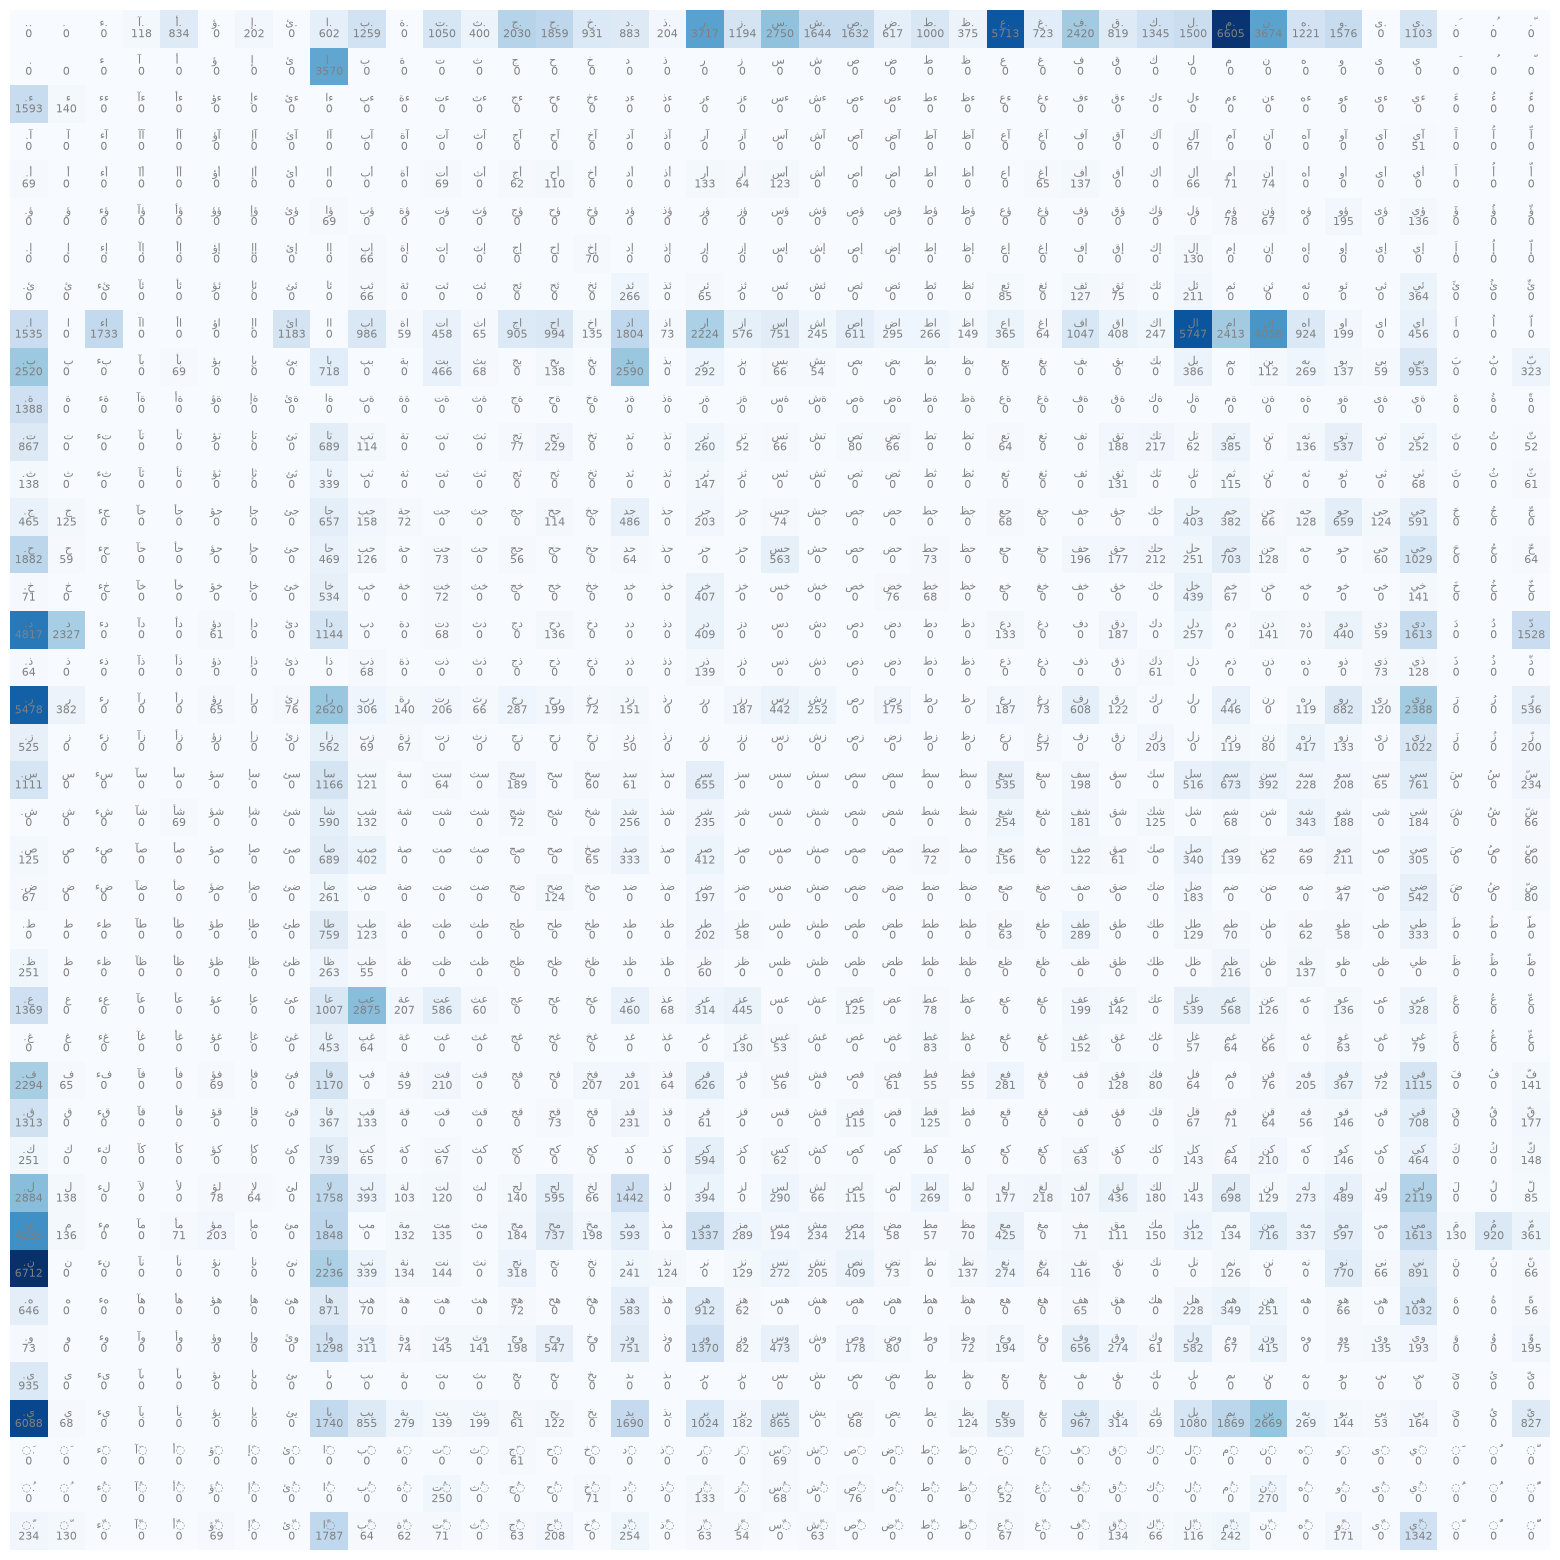

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20, 20))
plt.imshow(N, cmap='Blues')

for i in range(41):
    for j in range(41):
        chstr = itos[i] + itos[j]

        plt.text(j, i, chstr,
                 ha="center", va="bottom", color="gray", fontsize=8)

        plt.text(j, i, N[i, j].item(),
                 ha="center", va="top", color="gray", fontsize=8)

plt.axis('off');

In [15]:
N[0]

tensor([   0,    0,    0,  118,  834,    0,  202,    0,  602, 1259,    0, 1050,
         400, 2030, 1859,  931,  883,  204, 3717, 1194, 2750, 1644, 1632,  617,
        1000,  375, 5713,  723, 2420,  819, 1345, 1500, 6605, 3674, 1221, 1576,
           0, 1103,    0,    0,    0], dtype=torch.int32)

In [16]:
p = N.float()
p = p/p.sum(1, keepdim=True)

In [17]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    out = []
    ix = 0
    while True:
        P = p[ix]
        ix = torch.multinomial(P, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

ميظ.
ن.
بلحماهد.
جالل.
حي.


In [25]:
log_likelihood = 0.0
n = 0

for w in names[:3]:
    chrs = ['.'] + list(w) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        ix1 = stoi[char1]
        ix2 = stoi[char2]
        prob = p[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{char1}{char2}: {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.ز: -3.7347
زي: -1.2321
يد: -2.5874
د.: -1.0224
.و: -3.4571
وا: -1.8956
ائ: -3.2651
ئل: -1.7862
ل.: -1.5812
.م: -2.0242
مأ: -5.4666
أم: -2.6872
مو: -3.3373
ون: -3.0359
ن.: -0.7241
log_likelihood=tensor(-37.8371)
nll=tensor(37.8371)
2.522470235824585


In [26]:
xs , ys = [], []
for w in names:
    chrs = ['.'] + list(w) + ['.']
    for char1, char2 in zip(chrs, chrs[1:]):
        ix1 = stoi[char1]
        ix2 = stoi[char2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [33]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=41).float()

In [34]:
xenc.shape

torch.Size([284230, 41])

In [40]:
W = torch.randn((41, 41))
logits = xenc @ W
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)
probs.shape

torch.Size([284230, 41])